# 02 — Clasificación y análisis con LLM — Black Basta

Clasifica una muestra estratificada de mensajes con `qwen2.5:14b` y perfila los 49 actores.  
Con solo 49 actores (vs 485 en Conti) podemos ser más exhaustivos: 80 msgs/actor.

Produce:
- `data/processed/bb_sample_classified.parquet`
- `data/processed/bb_actor_profiles.json`


## 0. Setup

In [2]:
# sys y Path son herramientas estándar de Python para manejar el sistema de archivos.
import sys
from pathlib import Path

# Añadimos la carpeta 'src' a la lista de rutas donde Python busca módulos.
# Esto permite importar nuestro código personalizado con 'from loaders import ...'.
sys.path.insert(0, str(Path('src').resolve()))

# json es el módulo estándar de Python para leer y escribir ficheros JSON.
# JSON es un formato de texto muy usado para guardar datos estructurados
# (como diccionarios y listas) de forma legible.
import json

# time nos permite medir cuánto tiempo tarda un proceso y hacer pausas.
# Aquí lo usamos para calcular cuánto tiempo tarda la clasificación total.
import time

# pandas para trabajar con tablas de datos.
import pandas as pd

# ollama es la librería de Python para comunicarse con modelos de lenguaje (LLMs)
# que están corriendo localmente en el ordenador a través del servidor Ollama.
# Permite enviar mensajes al modelo y recibir sus respuestas.
import ollama

# tqdm muestra barras de progreso para bucles largos.
from tqdm.auto import tqdm

# Definimos todas las rutas de ficheros que usaremos en este notebook.
PROCESSED_DIR = Path('../data_Vruto/BlackBasta')

# Fichero de entrada: el dataset limpio generado por el notebook 01.
PARQUET_IN      = PROCESSED_DIR / 'blackbasta_unified.parquet'

# Fichero de salida: la muestra de mensajes con su categoría asignada por el LLM.
PARQUET_OUT     = PROCESSED_DIR / 'bb_sample_classified.parquet'

# Fichero de salida: los perfiles de cada actor inferidos por el LLM.
PROFILES_OUT    = PROCESSED_DIR / 'bb_actor_profiles.json'

# Fichero temporal de "checkpoint" para guardar el progreso durante la clasificación.
# Si el proceso se interrumpe, podemos retomarlo desde donde lo dejamos
# en lugar de empezar de cero.
CHECKPOINT_PATH = PROCESSED_DIR / 'bb_checkpoint_classified.parquet'

# Nombre del modelo de lenguaje local que usaremos para clasificar mensajes.
# qwen2.5:14b es un modelo de 14 mil millones de parámetros, potente y relativamente rápido.
MODEL = 'qwen2.5:14b'

# Si PARQUET_OUT y PROFILES_OUT ya existen (p.ej. vinieron precalculados en data_Vruto),
# nos saltamos la clasificación y el perfilado con el LLM más abajo y cargamos
# directamente los resultados ya guardados — así este notebook también se puede
# recorrer entero sin tener Ollama instalado.
ALREADY_DONE = PARQUET_OUT.exists() and PROFILES_OUT.exists()

# Verificamos que el fichero de entrada existe antes de continuar.
assert PARQUET_IN.exists(), f'No se encuentra {PARQUET_IN} — ejecuta primero el notebook 01'
print('Setup OK')

Setup OK


## 1. Cargar dataset

In [3]:
# Leemos el fichero Parquet generado en el notebook 01.
# read_parquet() carga el fichero directamente en un DataFrame de pandas.
# Es mucho más rápido que leer un CSV del mismo tamaño.
df = pd.read_parquet(PARQUET_IN)

# Mostramos estadísticas básicas para confirmar que los datos se cargaron bien.
print(f'Mensajes : {len(df):,}')
print(f'Actores  : {df.username.nunique()}')
print(f'Canales  : {df.channel.nunique()}')
print(f'Rango    : {df.timestamp.min().date()} → {df.timestamp.max().date()}')

Mensajes : 195,397
Actores  : 49
Canales  : 79
Rango    : 2023-09-18 → 2024-09-28


## 2. Muestreo — todos los actores, 80 msgs cada uno

Con 49 actores × 80 mensajes = ~3 900 mensajes.  
Muestra distribuida uniformemente en el tiempo por actor.

In [4]:
# Número máximo de mensajes que tomaremos por actor para la clasificación con LLM.
# Con 49 actores × 80 mensajes = ~3.900 mensajes en total, una cantidad manejable.
# No clasificamos los 195.000 mensajes porque llevaría demasiado tiempo con el LLM.
MSGS_PER_ACTOR = 80

# Descartamos actores con muy pocos mensajes porque una muestra de solo
# 1-2 mensajes no es representativa de cómo se comporta ese actor.
MIN_MSGS = 10

# Contamos mensajes por actor y nos quedamos solo con los que tienen suficientes.
actor_counts = df.groupby('username').size()
valid_actors = actor_counts[actor_counts >= MIN_MSGS].index.tolist()
print(f'Actores con ≥{MIN_MSGS} mensajes: {len(valid_actors)} de {df.username.nunique()}')


def sample_actor(actor_df: pd.DataFrame, n: int) -> pd.DataFrame:
    """
    Selecciona una muestra distribuida uniformemente en el tiempo para un actor.

    En lugar de tomar los primeros N mensajes (que solo cubren el inicio)
    o aleatorios (que pueden concentrarse en un periodo), elegimos mensajes
    espaciados uniformemente a lo largo de toda la historia del actor.
    Así la muestra es representativa de su actividad en el tiempo.

    Parámetros:
        actor_df (pd.DataFrame): Todos los mensajes de un actor concreto.
        n (int): Número máximo de mensajes a seleccionar.

    Devuelve:
        pd.DataFrame: Subconjunto de actor_df con como máximo n filas,
                      seleccionadas a intervalos regulares en el tiempo.
    """
    # Ordenamos los mensajes del actor de más antiguo a más reciente.
    actor_df = actor_df.sort_values('timestamp').reset_index(drop=True)

    # Si el actor tiene menos mensajes que el máximo pedido, los devolvemos todos.
    if len(actor_df) <= n:
        return actor_df

    # Calculamos n posiciones equidistantes entre 0 y el total de mensajes.
    # Por ejemplo, si el actor tiene 160 mensajes y pedimos 80,
    # indices sería [0, 2, 4, 6, ..., 158] (uno de cada dos).
    indices = [int(i * len(actor_df) / n) for i in range(n)]
    return actor_df.iloc[indices]


# Aplicamos la función de muestreo a cada actor válido y concatenamos los resultados.
# La lista 'frames' acumula el DataFrame de muestra de cada actor.
frames = [sample_actor(df[df['username'] == a], MSGS_PER_ACTOR) for a in valid_actors]

# pd.concat() combina todos los DataFrames de la lista en uno solo.
# ignore_index=True reasigna índices consecutivos en el resultado final.
# sort_values('timestamp') ordena todos los mensajes por fecha.
# reset_index(drop=True) limpia el índice después del ordenamiento.
sample = pd.concat(frames, ignore_index=True).sort_values('timestamp').reset_index(drop=True)

print(f'Muestra total: {len(sample):,} mensajes de {sample.username.nunique()} actores')

Actores con ≥10 mensajes: 47 de 49
Muestra total: 3,598 mensajes de 47 actores


## 3. Clasificación de mensajes

Mismas categorías que Conti para poder comparar entre grupos.

In [5]:
# Conjunto de categorías válidas. Usamos un set (conjunto) en lugar de una lista
# porque la búsqueda en sets es más rápida: 'x in set' va más rápido que 'x in lista'.
# Estas mismas categorías se usan también en el análisis de Conti, lo que permite
# comparar los dos grupos con métricas consistentes.
CATEGORIES = {'technical', 'operational', 'financial', 'organizational', 'comms', 'unknown'}

# El "system prompt" es la instrucción que le damos al LLM para que sepa
# qué rol debe jugar y cómo debe responder. Es como darle un briefing al modelo.
# Le pedimos que responda SOLO con el nombre de la categoría para poder procesar
# la respuesta fácilmente sin necesidad de parsear texto libre.
SYSTEM_PROMPT = """You are a threat intelligence analyst classifying messages from the leaked Black Basta ransomware group chats.
Messages are mostly in Russian. Classify each message into exactly one category:
- technical: malware development, builds, code, infrastructure, bugs, tools
- operational: attacks, targets, victims, accesses, deployment, reconnaissance
- financial: payments, bitcoin, ransom negotiations, money, commissions
- organizational: management, task assignments, team structure, HR, recruitment
- comms: general conversation, greetings, scheduling, off-topic
- unknown: too short or ambiguous to classify

Reply with ONLY the category name, nothing else."""


def classify_message(text: str) -> str:
    """
    Clasifica un mensaje en una de las categorías definidas usando el LLM local.

    Envía el mensaje al modelo de lenguaje (a través de Ollama) y recibe
    como respuesta el nombre de la categoría correspondiente.

    Parámetros:
        text (str): El texto del mensaje a clasificar.

    Devuelve:
        str: Una de las categorías: 'technical', 'operational', 'financial',
             'organizational', 'comms' o 'unknown'. Si el LLM devuelve algo
             inesperado o hay un error, devuelve 'unknown'.
    """
    # Mensajes muy cortos (menos de 5 caracteres) como "ok", "!", "+" no aportan
    # suficiente contexto para clasificarse correctamente. Los marcamos directamente.
    if len(text.strip()) < 5:
        return 'unknown'

    try:
        # Llamamos al modelo de lenguaje local a través de la API de Ollama.
        # messages es una lista de turnos de conversación (como un chat):
        #   - 'system': instrucciones generales para el modelo
        #   - 'user': el mensaje concreto a clasificar
        resp = ollama.chat(
            model=MODEL,
            messages=[
                {'role': 'system', 'content': SYSTEM_PROMPT},
                # Limitamos el mensaje a 400 caracteres para no exceder el contexto del modelo.
                {'role': 'user',   'content': f'Message: {text[:400]}'}
            ],
            # temperature=0 hace que el modelo sea determinista (siempre da la misma respuesta).
            # num_predict=10 limita la respuesta a 10 tokens; solo necesitamos una palabra.
            options={'temperature': 0, 'num_predict': 10}
        )

        # resp.message.content es el texto que devolvió el modelo.
        # .strip() elimina espacios; .lower() convierte a minúsculas.
        # .split()[0] se queda con la primera palabra (en caso de que responda más).
        # .rstrip('.,:') elimina posibles signos de puntuación al final.
        raw = resp.message.content.strip().lower().split()[0].rstrip('.,:')

        # Devolvemos la categoría si es válida; si no, 'unknown'.
        return raw if raw in CATEGORIES else 'unknown'

    except Exception:
        # Si hay cualquier error (red, modelo no disponible, respuesta vacía...),
        # devolvemos 'unknown' en lugar de interrumpir todo el proceso.
        return 'unknown'


# Probamos la función con dos ejemplos para verificar que funciona correctamente
# antes de lanzarla sobre los miles de mensajes de la muestra.
# Nos saltamos esta prueba si ya tenemos los resultados en caché — no hace falta
# tener Ollama levantado si no vamos a clasificar nada nuevo.
if not ALREADY_DONE:
    print('Test clasificación:')
    print(f'  técnico     → {classify_message("Нужно собрать новый билд для x64")}')
    print(f'  financiero  → {classify_message("переведи биткоины на кошелек")}')

In [6]:
if not ALREADY_DONE:
    # Comprobamos si existe un fichero de checkpoint de una ejecución anterior.
    # El checkpoint guarda los mensajes ya clasificados para no perder el progreso
    # si el proceso se interrumpe (p.ej. por un corte de luz o cierre del notebook).
    if CHECKPOINT_PATH.exists():
        # Si el checkpoint existe, cargamos los mensajes ya clasificados.
        done = pd.read_parquet(CHECKPOINT_PATH)

        # done.index contiene los índices de los mensajes ya procesados.
        # Lo convertimos a set para hacer búsquedas más rápidas luego.
        done_ids = set(done.index)
        print(f'Checkpoint: {len(done):,} mensajes ya clasificados')
    else:
        # Si no hay checkpoint, empezamos desde cero con estructuras vacías.
        done = pd.DataFrame()
        done_ids = set()
        print('Comenzando desde cero')

    # Filtramos la muestra para quedarnos solo con los mensajes que aún no
    # han sido clasificados. ~sample.index.isin(done_ids) es la negación:
    # selecciona los índices que NO están en done_ids.
    todo = sample[~sample.index.isin(done_ids)].copy()
    print(f'Pendientes: {len(todo):,}')
else:
    print(f'{PARQUET_OUT} ya existe — se cargará directamente en la siguiente celda, sin clasificar.')

../data_Vruto/BlackBasta/bb_sample_classified.parquet ya existe — se cargará directamente en la siguiente celda, sin clasificar.


In [7]:
if not ALREADY_DONE:
    # Cada cuántos mensajes guardamos el checkpoint.
    # Guardar con frecuencia protege contra interrupciones, pero hacerlo cada mensaje
    # sería demasiado lento. 50 es un buen compromiso.
    CHECKPOINT_EVERY = 50

    # Lista donde acumulamos los resultados (índice del mensaje + categoría asignada).
    results = []

    # Guardamos el tiempo de inicio para calcular cuánto tardó el proceso al final.
    t0 = time.time()

    # Iteramos sobre cada mensaje pendiente de clasificar.
    # tqdm() envuelve el iterador para mostrar una barra de progreso.
    # todo.iterrows() devuelve tuplas (índice, fila) para cada mensaje.
    # total=len(todo) es necesario para que tqdm sepa el total y calcule el tiempo restante.
    for i, (idx, row) in enumerate(tqdm(todo.iterrows(), total=len(todo), desc='Clasificando')):
        # Clasificamos el mensaje llamando a nuestra función que usa el LLM.
        cat = classify_message(row['message'])

        # Guardamos el índice original (para poder localizar el mensaje en 'sample')
        # y la categoría asignada.
        results.append({'idx': idx, 'category': cat})

        # Cada CHECKPOINT_EVERY mensajes, guardamos el progreso al disco.
        # Esto protege el trabajo en caso de que el proceso se interrumpa.
        if (i + 1) % CHECKPOINT_EVERY == 0:
            # Creamos un DataFrame temporal con los resultados nuevos.
            chunk = pd.DataFrame(results).set_index('idx')

            # Combinamos los ya clasificados (done) con los nuevos (chunk).
            # sample.loc[chunk.index] selecciona las filas de 'sample' por índice.
            # .assign(category=...) añade la columna 'category' con las categorías del chunk.
            partial = pd.concat([done, sample.loc[chunk.index].assign(category=chunk['category'])])

            # Guardamos el progreso al disco en formato Parquet.
            partial.to_parquet(CHECKPOINT_PATH)

    # Calculamos el tiempo total en segundos y lo convertimos a minutos.
    elapsed = time.time() - t0
    print(f'\nCompletado en {elapsed/60:.1f} min ({elapsed/max(len(todo),1):.1f} s/msg)')

    # Construimos el DataFrame final con todos los mensajes clasificados.
    # Creamos un DataFrame de los nuevos resultados, con el índice original del mensaje.
    new_df = pd.DataFrame(results).set_index('idx')

    # Recuperamos las filas originales de 'sample' correspondientes a esos índices.
    sample_new = sample.loc[new_df.index].copy()

    # Añadimos la columna 'category' con las categorías recién asignadas.
    sample_new['category'] = new_df['category'].values

    # Combinamos los mensajes del checkpoint anterior (done) con los nuevos.
    # sort_values y reset_index dejan el DataFrame ordenado y con índice limpio.
    classified = pd.concat([done, sample_new]).sort_values('timestamp').reset_index(drop=True)
    print(f'Total clasificados: {len(classified):,}')
else:
    # Ya tenemos el resultado final en disco — lo cargamos directamente en vez
    # de volver a clasificar mensaje a mensaje con el LLM.
    classified = pd.read_parquet(PARQUET_OUT)
    print(f'Cargados {len(classified):,} mensajes ya clasificados desde caché.')

Cargados 3,598 mensajes ya clasificados desde caché.


## 4. Análisis de resultados

In [8]:
# Importamos las librerías necesarias para los gráficos de esta sección.
import matplotlib.pyplot as plt
import numpy as np

# Definimos el orden en que queremos mostrar las categorías en los gráficos.
# Las categorías más informativas (technical, operational) van primero.
cat_order = ['technical', 'operational', 'financial', 'organizational', 'comms', 'unknown']

# Filtramos para quedarnos solo con las categorías que realmente aparecen en los datos
# (por si alguna no fue asignada a ningún mensaje en esta ejecución).
cat_order = [c for c in cat_order if c in classified['category'].unique()]

# Mostramos cuántos mensajes hay de cada categoría.
# value_counts() ya ordena de mayor a menor por defecto.
print('=== Distribución global de categorías ===')
cat_counts = classified['category'].value_counts()
print(cat_counts.to_string())

=== Distribución global de categorías ===
category
technical         1054
comms             1051
unknown            777
operational        543
financial          122
organizational      51


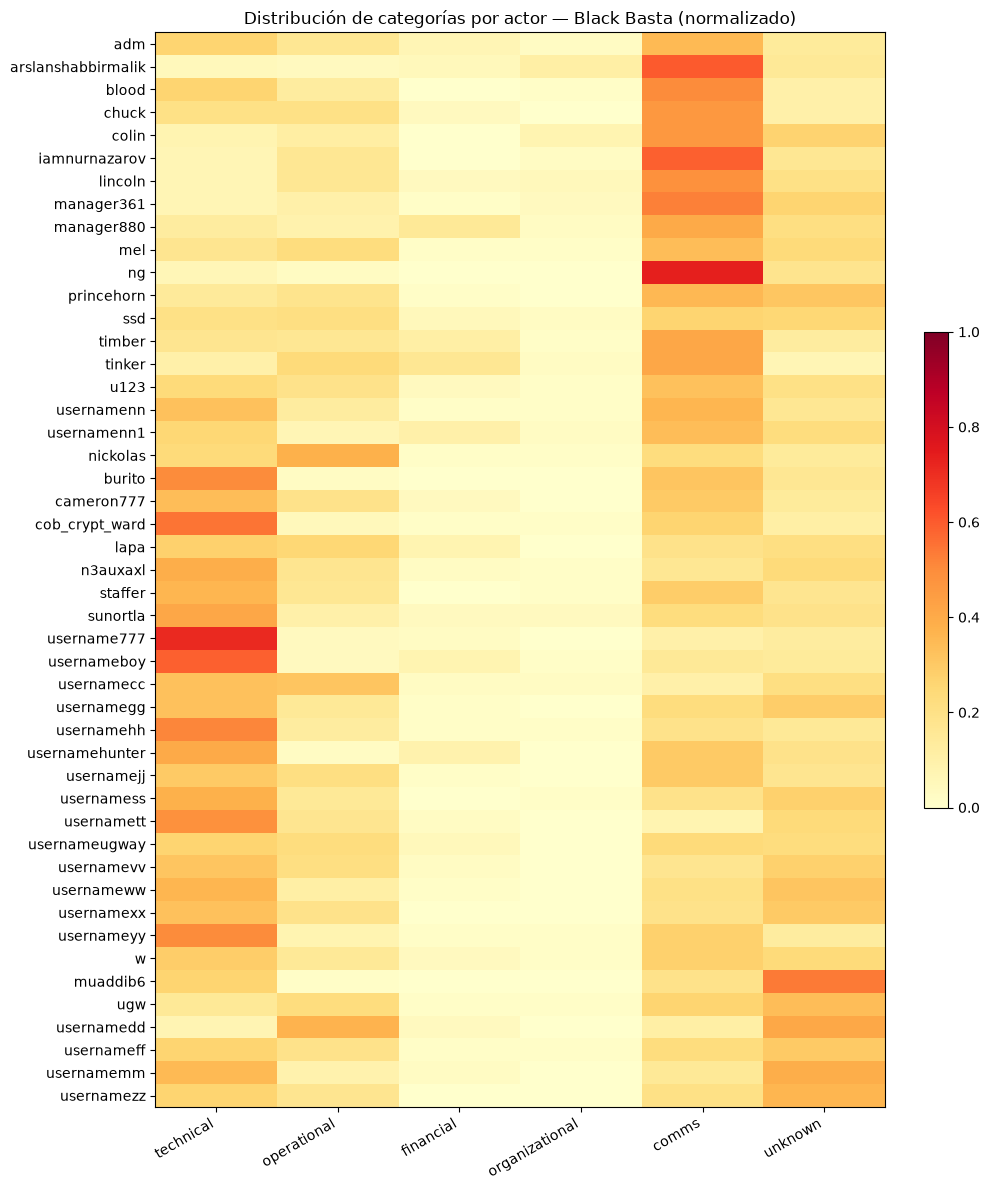

In [9]:
# Construimos una "tabla pivote" que muestra cuántos mensajes de cada categoría
# tiene cada actor. El resultado es una tabla donde:
#   - Cada fila es un actor (username)
#   - Cada columna es una categoría
#   - Cada celda contiene el número de mensajes de ese actor en esa categoría
# groupby(['username', 'category']).size() cuenta todas las combinaciones actor+categoría.
# unstack() convierte las categorías de filas a columnas.
# fill_value=0 rellena con 0 los actores que no tienen mensajes de alguna categoría.
pivot = classified.groupby(['username', 'category']).size().unstack(fill_value=0)

# Normalizamos las cuentas dividiendo cada fila entre su total.
# div(pivot.sum(axis=1), axis=0) divide cada fila entre la suma de esa fila,
# convirtiendo los conteos absolutos en proporciones (entre 0 y 1).
# Así podemos comparar actores aunque tengan muy distinto número de mensajes.
pivot_norm = pivot.div(pivot.sum(axis=1), axis=0)

# Reordenamos las columnas según cat_order para que el gráfico sea coherente.
pivot_norm = pivot_norm[[c for c in cat_order if c in pivot_norm.columns]]

# Ordenamos los actores por la categoría en la que más destacan.
# idxmax(axis=1) devuelve, para cada actor, la categoría con mayor proporción.
# sort_values().index devuelve los actores ordenados alfabéticamente por esa categoría.
# Esto agrupa a actores similares juntos en el heatmap.
pivot_norm = pivot_norm.loc[pivot_norm.idxmax(axis=1).sort_values().index]

# Creamos el heatmap (mapa de calor) con imshow().
# Un heatmap muestra valores numéricos como colores: aquí, más oscuro = mayor proporción.
fig, ax = plt.subplots(figsize=(10, 12))

# imshow() dibuja la matriz de valores como una imagen de colores.
# aspect='auto' ajusta el ancho de las celdas automáticamente.
# cmap='YlOrRd' es la paleta de colores: amarillo (bajo) → naranja → rojo (alto).
# vmin=0, vmax=1 establece el rango de la escala de color (de 0% a 100%).
im = ax.imshow(pivot_norm.values, aspect='auto', cmap='YlOrRd', vmin=0, vmax=1)

# Ponemos etiquetas en los ejes X (categorías) e Y (actores).
ax.set_xticks(range(len(pivot_norm.columns)))
ax.set_xticklabels(pivot_norm.columns, rotation=30, ha='right')
ax.set_yticks(range(len(pivot_norm)))
ax.set_yticklabels(pivot_norm.index)

ax.set_title('Distribución de categorías por actor — Black Basta (normalizado)')

# Añadimos una barra de color a la derecha que explica la escala.
# fraction=0.03 hace la barra estrecha para que no ocupe demasiado espacio.
plt.colorbar(im, ax=ax, fraction=0.03)
plt.tight_layout()
plt.show()

## 5. Perfilado de actores

In [10]:
if not ALREADY_DONE:
    # El "system prompt" para el perfilado de actores.
    # A diferencia de la clasificación de mensajes individuales, aquí le pedimos al LLM
    # que lea VARIOS mensajes de un mismo actor y deduzca su rol dentro de la organización.
    # Le pedimos respuesta en formato JSON para poder procesarla automáticamente.
    PROFILE_SYSTEM = """You are a threat intelligence analyst studying the Black Basta ransomware group.
Given a sample of messages from one member, infer their role in the organization.

Reply in JSON with these fields:
{
  "role": "<one of: leader, developer, operator, negotiator, affiliate, support, unknown>",
  "confidence": "<high|medium|low>",
  "summary": "<2-3 sentences in English describing their responsibilities>",
  "evidence": ["<quote or paraphrase from messages, max 3>"]
}"""


    def profile_actor(actor: str, messages: list[str]) -> dict:
        """
        Genera un perfil del rol de un actor dentro del grupo Black Basta.

        Envía hasta 30 mensajes del actor al LLM y le pide que infiera
        su función en la organización criminal, devolviendo un diccionario
        con el rol, la confianza y un resumen en inglés.

        Parámetros:
            actor (str): Nombre de usuario del actor a perfilar.
            messages (list[str]): Lista de mensajes del actor.

        Devuelve:
            dict: Diccionario con las claves 'role', 'confidence', 'summary'
                  y 'evidence'. Si hay algún error al parsear la respuesta del LLM,
                  devuelve un diccionario con 'role': 'unknown' y el error en 'summary'.
        """
        # Formateamos los mensajes como una lista con guiones para el prompt.
        # Limitamos cada mensaje a 200 caracteres y usamos solo los primeros 30
        # para no exceder el límite de contexto del modelo.
        msg_block = '\n'.join(f'- {m[:200]}' for m in messages[:30])

        try:
            # Enviamos el bloque de mensajes al LLM pidiéndole que infiera el rol.
            resp = ollama.chat(
                model=MODEL,
                messages=[
                    {'role': 'system', 'content': PROFILE_SYSTEM},
                    {'role': 'user',   'content': f'Actor: {actor}\n\nMessages:\n{msg_block}'}
                ],
                # temperature=0.1 permite algo de variación creativa en el resumen,
                # más que con 0 (que sería completamente determinista).
                # num_predict=300 deja espacio suficiente para el JSON completo.
                options={'temperature': 0.1, 'num_predict': 300}
            )

            # Extraemos el texto de la respuesta.
            raw   = resp.message.content.strip()

            # El modelo a veces añade texto antes o después del JSON.
            # find('{') localiza donde empieza el objeto JSON.
            # rfind('}') + 1 localiza donde termina (rfind busca desde el final).
            start = raw.find('{')
            end   = raw.rfind('}') + 1

            # json.loads() convierte el texto JSON en un diccionario de Python.
            return json.loads(raw[start:end])

        except Exception as e:
            # Si algo falla (JSON malformado, error de red, etc.), devolvemos
            # un perfil vacío con el mensaje de error para poder investigarlo después.
            return {'role': 'unknown', 'confidence': 'low', 'summary': str(e), 'evidence': []}


    # Diccionario donde guardaremos el perfil de cada actor.
    # Las claves son nombres de usuario y los valores son los diccionarios de perfil.
    actor_profiles = {}

    # Iteramos sobre todos los actores válidos y los perfilamos uno a uno.
    # tqdm muestra una barra de progreso para este bucle que puede tardar varios minutos.
    for actor in tqdm(valid_actors, desc='Perfilando actores'):
        # Obtenemos todos los mensajes del actor desde el DataFrame ya clasificado.
        msgs = classified[classified['username'] == actor]['message'].tolist()

        # Llamamos a la función de perfilado y guardamos el resultado.
        actor_profiles[actor] = profile_actor(actor, msgs)

    # Imprimimos un resumen de los roles inferidos para todos los actores.
    print('\n=== ROLES INFERIDOS ===')
    for actor, profile in actor_profiles.items():
        role = profile.get('role', '?')
        conf = profile.get('confidence', '?')
        # Recortamos el resumen a 80 caracteres para que quepa en una línea.
        summ = profile.get('summary', '')[:80]
        print(f'  {actor:<20} [{role:<15}] ({conf:<6}) — {summ}')
else:
    # Ya tenemos los perfiles en disco — los cargamos directamente en vez de
    # volver a perfilar actor a actor con el LLM.
    with open(PROFILES_OUT, encoding='utf-8') as f:
        actor_profiles = json.load(f)
    print(f'Cargados {len(actor_profiles):,} perfiles de actores desde caché.')

Cargados 47 perfiles de actores desde caché.


## 6. Guardar

In [11]:
if ALREADY_DONE:
    print(f'Ya existen, no se regeneran: {PARQUET_OUT.name}, {PROFILES_OUT.name}')
else:
    # Guardamos los mensajes clasificados en formato Parquet para el notebook 03.
    # index=False evita guardar el número de fila como columna extra.
    classified.to_parquet(PARQUET_OUT, index=False)

    # Guardamos los perfiles de los actores en formato JSON.
    # open con 'w' abre el fichero para escritura (lo crea si no existe, lo sobreescribe si existe).
    # json.dump() serializa el diccionario Python a texto JSON.
    # indent=2 hace el JSON legible con sangrías de 2 espacios.
    # ensure_ascii=False permite guardar caracteres no-ASCII (como el cirílico) directamente
    # en lugar de convertirlos a secuencias de escape (\uXXXX).
    with open(PROFILES_OUT, 'w', encoding='utf-8') as f:
        json.dump(actor_profiles, f, indent=2, ensure_ascii=False)

    # Eliminamos el fichero de checkpoint temporal ya que el proceso ha terminado.
    # exists() comprueba primero que el fichero existe para evitar un error.
    # unlink() borra el fichero.
    if CHECKPOINT_PATH.exists():
        CHECKPOINT_PATH.unlink()

    # Confirmamos que todo se guardó correctamente.
    print(f'Muestra clasificada → {PARQUET_OUT}')
    print(f'Perfiles de actores → {PROFILES_OUT}')

print(f'\nResumen: {len(classified):,} msgs | {len(actor_profiles)} actores perfilados')

Ya existen, no se regeneran: bb_sample_classified.parquet, bb_actor_profiles.json

Resumen: 3,598 msgs | 47 actores perfilados
